In [ ]:
!pip install -q kaggle
!pip install -q bertopic
!pip install -q sentence-transformers
!pip install -q gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 90.0 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hongvnti","key":"9e6c52afde18a2a3c457ab91db880108"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d mohamedbakhet/amazon-books-reviews
!unzip amazon-books-reviews.zip


Dataset URL: https://www.kaggle.com/datasets/mohamedbakhet/amazon-books-reviews
License(s): CC0-1.0
 99% 1.05G/1.06G [00:15<00:00, 40.7MB/s]
100% 1.06G/1.06G [00:15<00:00, 72.8MB/s]
Archive:  amazon-books-reviews.zip
  inflating: Books_rating.csv        
  inflating: books_data.csv          


In [ ]:
import pandas as pd

df = pd.read_csv("Books_rating.csv")

print(df.shape)
df.head()


(3000000, 10)


,Id,Title,Price,User_id,profileName,review/helpfulness,review/score,review/time,review/summary,review/text
0,1882931173,Its Only Art If Its Well Hung!,NaN,AVCGYZL8FQQTD,"Jim of Oz ""jim-of-oz""",7/7,4.0,940636800,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...
1,0826414346,Dr. Seuss: American Icon,NaN,A30TK6U7DNS82R,Kevin Killian,10/10,5.0,1095724800,Really Enjoyed It,I don't care much for Dr. Seuss but after read...
2,0826414346,Dr. Seuss: American Icon,NaN,A3UH4UZ4RSVO82,John Granger,10/11,5.0,1078790400,Essential for every personal and Public Library,"If people become the books they read and if ""t..."
3,0826414346,Dr. Seuss: American Icon,NaN,A2MVUWT453QH61,"Roy E. Perry ""amateur philosopher""",7/7,4.0,1090713600,Phlip Nel gives silly Seuss a serious treatment,"Theodore Seuss Geisel (1904-1991), aka &quot;D..."
4,0826414346,Dr. Seuss: American Icon,NaN,A22X4XUPKF66MR,"D. H. Richards ""ninthwavestore""",3/3,4.0,1107993600,Good academic overview,Philip Nel - Dr. Seuss: American IconThis is b...


In [ ]:
df = df.rename(columns={
    'User_id': 'user_id',
    'review/score': 'rating',
    'review/text': 'review_text',
    'review/summary': 'summary',
    'review/helpfulness': 'helpfulness'
})


In [ ]:
df = df.dropna(subset=['rating', 'review_text'])


In [ ]:
df['review_length'] = df['review_text'].apply(
    lambda x: len(str(x).split())
)


In [ ]:
def parse_helpfulness(h):
    try:
        x, y = h.split('/')
        return int(x) / int(y) if int(y) != 0 else 0
    except:
        return 0

df['helpfulness_ratio'] = df['helpfulness'].astype(str).apply(parse_helpfulness)


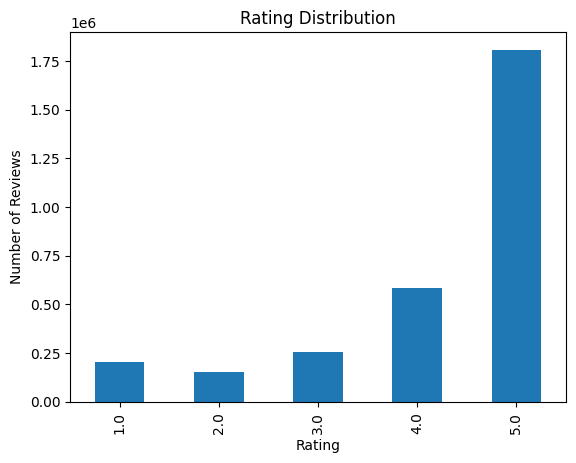

In [ ]:
import matplotlib.pyplot as plt

df['rating'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.title('Rating Distribution')
plt.show()


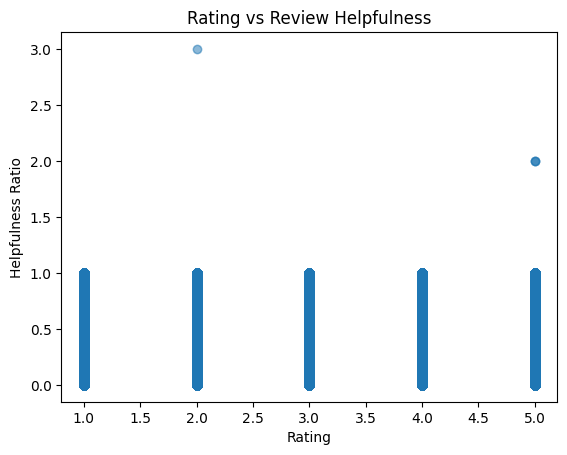

In [ ]:
plt.scatter(df['rating'], df['helpfulness_ratio'], alpha=0.3)
plt.xlabel('Rating')
plt.ylabel('Helpfulness Ratio')
plt.title('Rating vs Review Helpfulness')
plt.show()


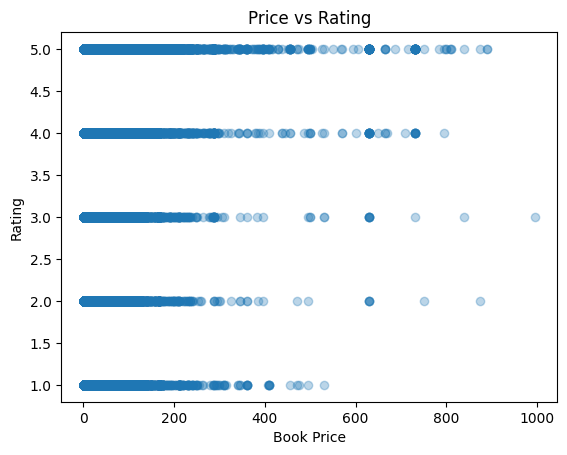

In [ ]:
df_price = df.dropna(subset=['Price'])

plt.scatter(df_price['Price'], df_price['rating'], alpha=0.3)
plt.xlabel('Book Price')
plt.ylabel('Rating')
plt.title('Price vs Rating')
plt.show()


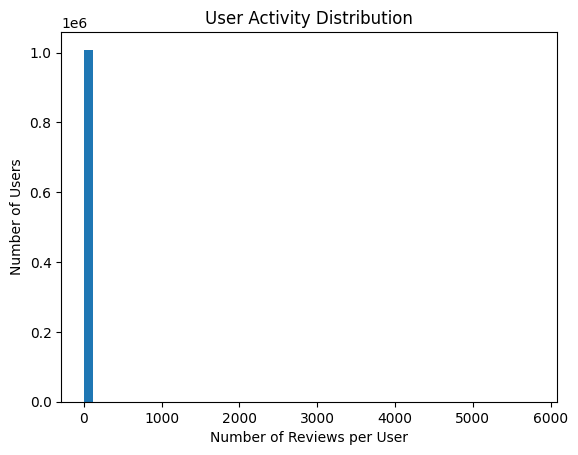

In [ ]:
user_activity = df.groupby('user_id').size()

plt.hist(user_activity, bins=50)
plt.xlabel('Number of Reviews per User')
plt.ylabel('Number of Users')
plt.title('User Activity Distribution')
plt.show()


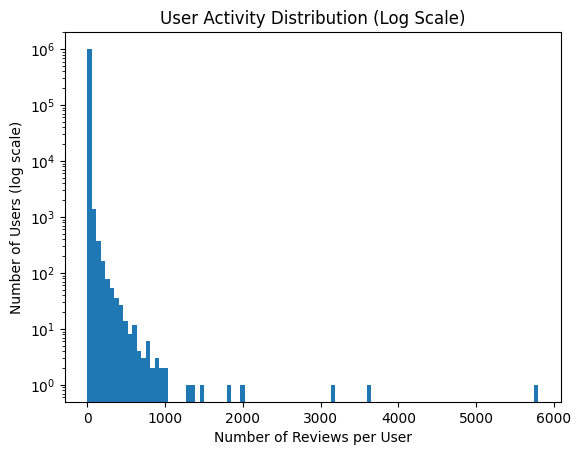

In [ ]:
import matplotlib.pyplot as plt

plt.hist(user_activity, bins=100, log=True)
plt.xlabel('Number of Reviews per User')
plt.ylabel('Number of Users (log scale)')
plt.title('User Activity Distribution (Log Scale)')
plt.show()

In [ ]:
texts = (
    df['summary'].fillna('') + ' ' +
    df['review_text'].fillna('')
).astype(str).tolist()


In [ ]:
import numpy as np

np.random.seed(42)
sample_size = 50000

idx = np.random.choice(len(texts), sample_size, replace=False)
texts_sample = [texts[i] for i in idx]


In [ ]:
import re

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

texts_sample = [preprocess(t) for t in texts_sample]


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words='english',
    max_df=0.6,
    min_df=30,
    max_features=30000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(texts_sample)

print("Kích thước ma trận Bag-of-Words:", X.shape)


Kích thước ma trận Bag-of-Words: (50000, 13957)


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt

k_values = [5, 10, 15, 20, 30]
perplexities = []
log_likelihoods = []

for k in k_values:
    print(f"\n===== Training LDA với k = {k} topics =====")

    lda = LatentDirichletAllocation(
        n_components=k,
        max_iter=15,
        learning_method='batch',
        random_state=42,
        n_jobs=-1
    )

    lda.fit(X)

    perplexities.append(lda.perplexity(X))
    log_likelihoods.append(lda.score(X))

    print(f"Perplexity = {perplexities[-1]:.2f}")
    print(f"Log-likelihood = {log_likelihoods[-1]:.2f}")



===== Training LDA với k = 5 topics =====
Perplexity = 3838.73
Log-likelihood = -26073241.94

===== Training LDA với k = 10 topics =====
Perplexity = 3746.10
Log-likelihood = -25996073.76

===== Training LDA với k = 15 topics =====
Perplexity = 3719.04
Log-likelihood = -25973175.15

===== Training LDA với k = 20 topics =====
Perplexity = 3731.48
Log-likelihood = -25983721.60

===== Training LDA với k = 30 topics =====
Perplexity = 3804.64
Log-likelihood = -26045059.77


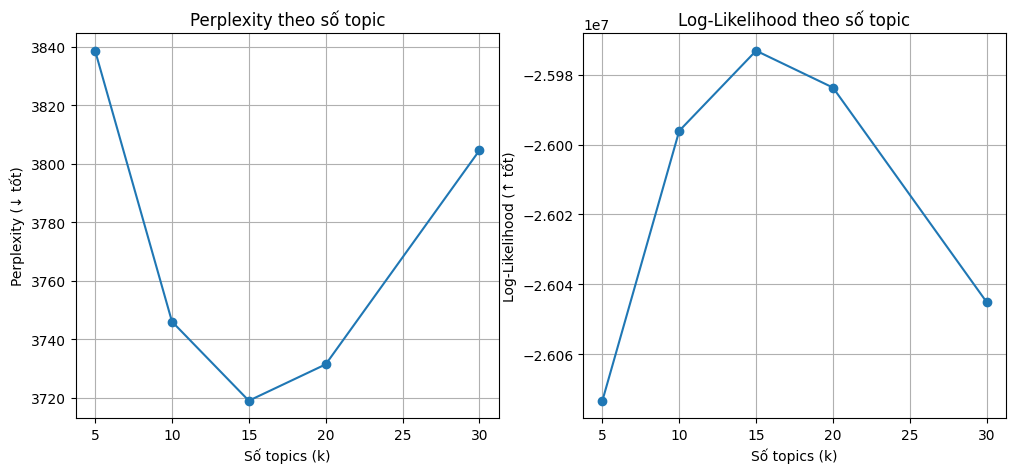

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(k_values, perplexities, marker='o')
plt.xlabel("Số topics (k)")
plt.ylabel("Perplexity (↓ tốt)")
plt.title("Perplexity theo số topic")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(k_values, log_likelihoods, marker='o')
plt.xlabel("Số topics (k)")
plt.ylabel("Log-Likelihood (↑ tốt)")
plt.title("Log-Likelihood theo số topic")
plt.grid(True)

plt.show()


In [ ]:
feature_names = vectorizer.get_feature_names_out()

def print_topics(model, feature_names, n_top_words=15):
    for idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[-n_top_words:][::-1]
        words = [feature_names[i] for i in top_idx]
        print(f"\n=== Topic {idx} ===")
        print(", ".join(words))
final_k = 15

lda_final = LatentDirichletAllocation(
    n_components=final_k,
    max_iter=15,
    learning_method='batch',
    random_state=42,
    n_jobs=-1
)

lda_final.fit(X)

print_topics(lda_final, feature_names)



=== Topic 0 ===
like, read, really, good, just, dont, think, know, people, reading, didnt, did, im, thought, want

=== Topic 1 ===
war, history, american, world, time, people, america, years, historical, life, country, political, great, century, men

=== Topic 2 ===
god, christian, bible, church, faith, jesus, read, philosophy, life, religion, religious, lewis, christianity, christ, gods

=== Topic 3 ===
love, women, novel, woman, jane, young, family, characters, men, life, mr, man, little, austen, marriage

=== Topic 4 ===
great, buy, bought, good, books, just, copy, cover, time, new, money, like, pictures, old, little

=== Topic 5 ===
world, human, life, story, society, novel, lord, people, reader, hobbit, fantasy, evil, nature, man, rings

=== Topic 6 ===
people, life, way, make, work, does, need, like, think, real, just, business, right, things, change

=== Topic 7 ===
science, time, author, like, work, fiction, read, authors, fact, does, point, written, think, writing, just

=== 

In [ ]:
doc_id = 1000

doc_vector = X[doc_id]
topic_dist = lda_final.transform(doc_vector)

print(f"\nPhân phối topic của review {doc_id}:\n")
for i, val in enumerate(topic_dist[0]):
    print(f"Topic {i}: {val:.4f}")

print("\nNội dung review:")
print(texts[doc_id][:500], "...")



Phân phối topic của review 1000:

Topic 0: 0.1445
Topic 1: 0.0333
Topic 2: 0.0005
Topic 3: 0.1313
Topic 4: 0.0714
Topic 5: 0.0005
Topic 6: 0.0005
Topic 7: 0.0005
Topic 8: 0.0005
Topic 9: 0.0005
Topic 10: 0.3661
Topic 11: 0.2487
Topic 12: 0.0005
Topic 13: 0.0005
Topic 14: 0.0005

Nội dung review:
So Jean Hill is no John Dean Just some thoughts on Jean Hill and her book.The only book I've purchased and read so far regarding the JFK assassination that gives you an insight on how (in this case) one of the witnesses life was affected by being in Dealy Plaza on that fateful day.She like most of the witnesses in Dealy Plaza said that she thought the shots came from the 'Grassy knoll'. She was man handled by so-called 'secret agents' 'Magic bullet man' also grilled her about her affair with a D ...


In [ ]:
!pip install bertopic[all]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 8.0 MB/s eta 0:00:00


In [ ]:
from bertopic import BERTopic

# Train BERTopic
topic_model = BERTopic(language="english", calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(texts)

print("Số topic BERTopic tìm được:", len(set(topics)) - 1)


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
2025-12-03 01:41:55,524 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/589 [00:00<?, ?it/s]

2025-12-03 01:43:15,657 - BERTopic - Embedding - Completed ✓
2025-12-03 01:43:15,658 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-03 01:44:04,661 - BERTopic - Dimensionality - Completed ✓
2025-12-03 01:44:04,663 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-03 01:44:38,711 - BERTopic - Cluster - Completed ✓
2025-12-03 01:44:38,728 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-03 01:44:41,668 - BERTopic - Representation - Completed ✓


Số topic BERTopic tìm được: 215


In [ ]:
for i in range(5):
    print(f"\n=== BERTopic Topic {i} ===")
    print(topic_model.get_topic(i))



=== BERTopic Topic 0 ===
[('game', np.float64(0.010373686421414155)), ('team', np.float64(0.009040416822478477)), ('games', np.float64(0.007200733227048788)), ('he', np.float64(0.007084773667351757)), ('players', np.float64(0.00633626343453708)), ('season', np.float64(0.006254796944964913)), ('hockey', np.float64(0.0061306422969871046)), ('play', np.float64(0.005790128873906248)), ('25', np.float64(0.005658411940929887)), ('year', np.float64(0.00563227791517075))]

=== BERTopic Topic 1 ===
[('key', np.float64(0.014113757764660857)), ('clipper', np.float64(0.012708668097459483)), ('chip', np.float64(0.0119728021452251)), ('encryption', np.float64(0.011520112024564601)), ('keys', np.float64(0.009756608521238752)), ('escrow', np.float64(0.008436686183929827)), ('government', np.float64(0.008318384464503907)), ('nsa', np.float64(0.0075326224275121334)), ('algorithm', np.float64(0.0068143488312790105)), ('be', np.float64(0.006327785930732305))]

=== BERTopic Topic 2 ===
[('ites', np.float6

In [ ]:
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.6 MB/s eta 0:00:00


In [ ]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

# Tokenize dữ liệu
tokenized_texts = [doc.split() for doc in texts]

dictionary = Dictionary(tokenized_texts)
corpus = [dictionary.doc2bow(text) for text in tokenized_texts]

# Tạo list topic LDA (top từ)
lda_topics = []
for comp in lda_final.components_:
    top_idx = comp.argsort()[-10:]
    lda_topics.append([feature_names[i] for i in top_idx])

# BERTopic topics
bertopic_topics = []
for i in range(len(set(topics)) - 1):
    topic_words = [w for w, p in topic_model.get_topic(i)]
    bertopic_topics.append(topic_words)

# Coherence LDA
cm_lda = CoherenceModel(topics=lda_topics,
                        texts=tokenized_texts,
                        dictionary=dictionary,
                        coherence='c_v')

coh_lda = cm_lda.get_coherence()

# Coherence BERTopic
cm_bertopic = CoherenceModel(topics=bertopic_topics,
                             texts=tokenized_texts,
                             dictionary=dictionary,
                             coherence='c_v')

coh_bertopic = cm_bertopic.get_coherence()

print("Coherence LDA:", coh_lda)
print("Coherence BERTopic:", coh_bertopic)


Coherence LDA: 0.4898329535417038
Coherence BERTopic: 0.45328569151795456
